# PHASE 3 — Load Dataset

In [1]:
import pandas as pd

df = pd.read_csv("../dataset/traffic.csv")

print(df.head())

              DateTime  Junction  Vehicles           ID
0  2015-11-01 00:00:00         1        15  20151101001
1  2015-11-01 01:00:00         1        13  20151101011
2  2015-11-01 02:00:00         1        10  20151101021
3  2015-11-01 03:00:00         1         7  20151101031
4  2015-11-01 04:00:00         1         9  20151101041


# PHASE 4 — Understand Dataset

In [2]:
print(df.shape)

print(df.info())

print(df.describe())

print(df.isnull().sum())

(48120, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None
           Junction      Vehicles            ID
count  48120.000000  48120.000000  4.812000e+04
mean       2.180549     22.791334  2.016330e+10
std        0.966955     20.750063  5.944854e+06
min        1.000000      1.000000  2.015110e+10
25%        1.000000      9.000000  2.016042e+10
50%        2.000000     15.000000  2.016093e+10
75%        3.000000     29.000000  2.017023e+10
max        4.000000    180.000000  2.017063e+10
DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64


# PHASE 5 — Data Preprocessing

In [3]:
df['DateTime'] = pd.to_datetime(df['DateTime'])

df['year'] = df['DateTime'].dt.year
df['month'] = df['DateTime'].dt.month
df['day'] = df['DateTime'].dt.day
df['hour'] = df['DateTime'].dt.hour
df['dayofweek'] = df['DateTime'].dt.dayofweek

df.drop('DateTime', axis=1, inplace=True)

print(df.head())

   Junction  Vehicles           ID  year  month  day  hour  dayofweek
0         1        15  20151101001  2015     11    1     0          6
1         1        13  20151101011  2015     11    1     1          6
2         1        10  20151101021  2015     11    1     2          6
3         1         7  20151101031  2015     11    1     3          6
4         1         9  20151101041  2015     11    1     4          6


# PHASE 6 — Data Visualization

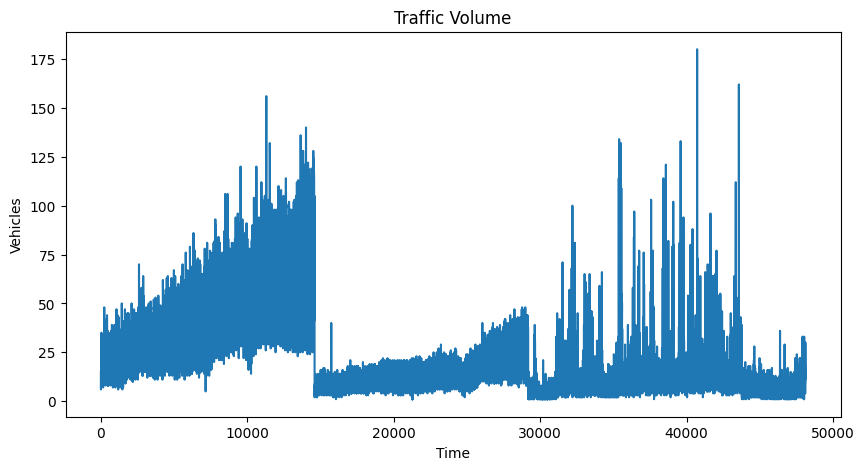

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Vehicles'])
plt.title("Traffic Volume")
plt.xlabel("Time")
plt.ylabel("Vehicles")
plt.show()

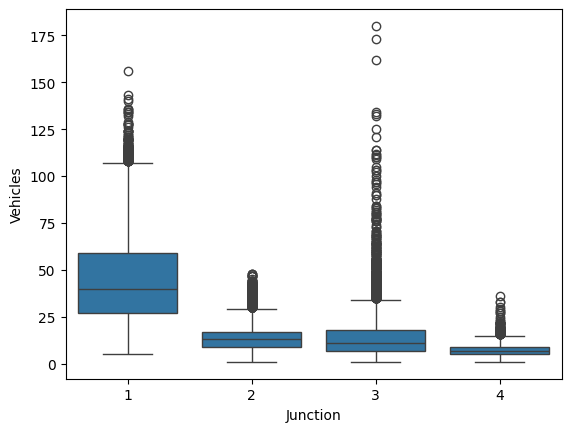

In [5]:
import seaborn as sns

sns.boxplot(x='Junction', y='Vehicles', data=df)
plt.show()

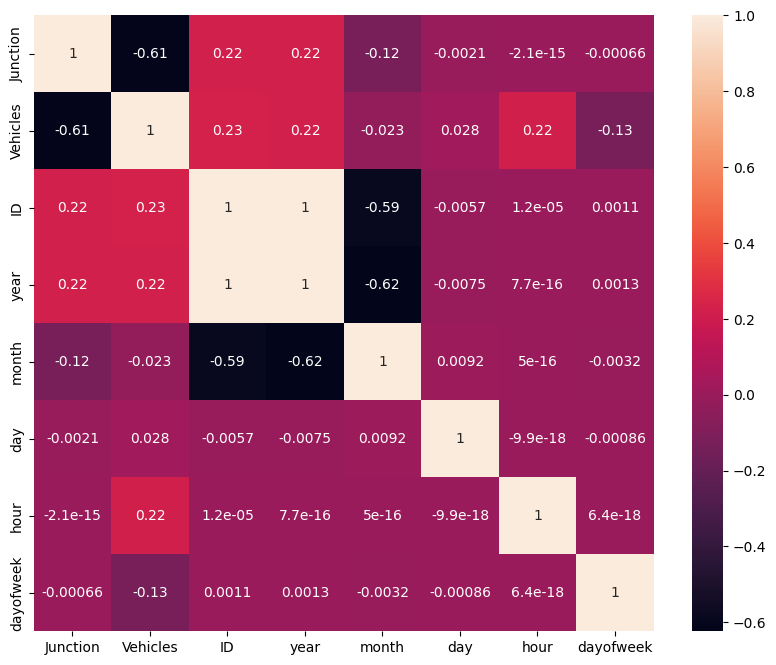

In [6]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

# PHASE 7 — Regression Problem

In [7]:
X = df.drop('Vehicles', axis=1)
y = df['Vehicles']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# PHASE 8 — Apply Regression Models

In [8]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

In [9]:
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)

C:\Users\piyus\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=7.27531e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


In [10]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
poly_model = make_pipeline(
    PolynomialFeatures(2),
    LinearRegression()
)
poly_model.fit(X_train, y_train)
pred_poly = poly_model.predict(X_test)

In [11]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
svr = SVR()
svr.fit(X_train_scaled, y_train)
pred_svr = svr.predict(X_test_scaled)

# PHASE 9 — Ensemble Models

In [12]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [13]:
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)

In [14]:
from xgboost import XGBRegressor
xgb = XGBRegressor()
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

# PHASE 10 — Evaluation Metrics

In [15]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
import numpy as np

def evaluate(y_test, pred, name):
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print(f"{name}")
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2:", r2)
    print("---------------------")

evaluate(y_test, pred_lr, "Linear Regression")
evaluate(y_test, pred_ridge, "Ridge Regression")
evaluate(y_test, pred_poly, "Polynomial Regression")
evaluate(y_test, pred_svr, "SVR")
evaluate(y_test, pred_rf, "Random Forest")
evaluate(y_test, pred_gb, "Gradient Boosting")
evaluate(y_test, pred_xgb, "XGBoost")

Linear Regression
MSE: 163.124844490881
RMSE: 12.772033686570083
MAE: 9.63767609602927
R2: 0.5997395466492057
---------------------
Ridge Regression
MSE: 163.12451291028606
RMSE: 12.772020705835317
MAE: 9.637598542324945
R2: 0.5997403602505897
---------------------
Polynomial Regression
MSE: 163.09880274172224
RMSE: 12.771014162615366
MAE: 9.637004867892616
R2: 0.5998034454523393
---------------------
SVR
MSE: 56.320077274334736
RMSE: 7.504670364135571
MAE: 4.488816681460916
R2: 0.8618070733925685
---------------------
Random Forest
MSE: 12.383786990856192
RMSE: 3.5190605267395147
MAE: 2.359850374064838
R2: 0.9696138242422241
---------------------
Gradient Boosting
MSE: 35.71866727711872
RMSE: 5.976509623276677
MAE: 3.707584333501456
R2: 0.9123568822269441
---------------------
XGBoost
MSE: 16.70273208618164
RMSE: 4.086897611414022
MAE: 2.5137274265289307
R2: 0.9590163826942444
---------------------


# PHASE 11 — Result Comparison Table

In [16]:
results = pd.DataFrame({
    'Model': [
        'Linear',
        'Ridge',
        'Polynomial',
        'SVR',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost'
    ],
    'R2 Score': [
        r2_score(y_test, pred_lr),
        r2_score(y_test, pred_ridge),
        r2_score(y_test, pred_poly),
        r2_score(y_test, pred_svr),
        r2_score(y_test, pred_rf),
        r2_score(y_test, pred_gb),
        r2_score(y_test, pred_xgb)
    ]
})
print(results)

               Model  R2 Score
0             Linear  0.599740
1              Ridge  0.599740
2         Polynomial  0.599803
3                SVR  0.861807
4      Random Forest  0.969614
5  Gradient Boosting  0.912357
6            XGBoost  0.959016


# PHASE 12 — Visualization of Results

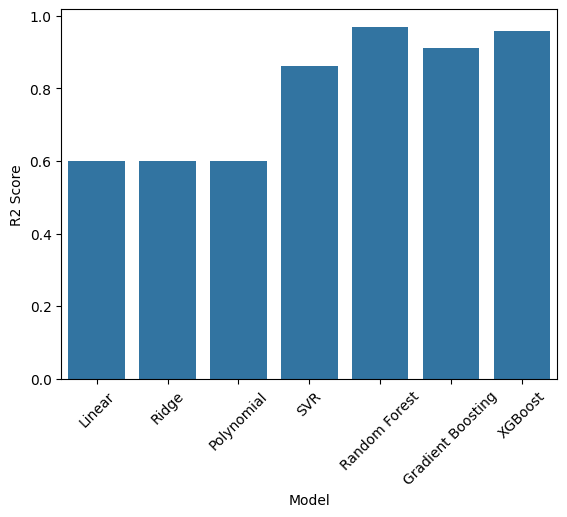

In [17]:
sns.barplot(
    x='Model',
    y='R2 Score',
    data=results
)
plt.xticks(rotation=45)
plt.show()

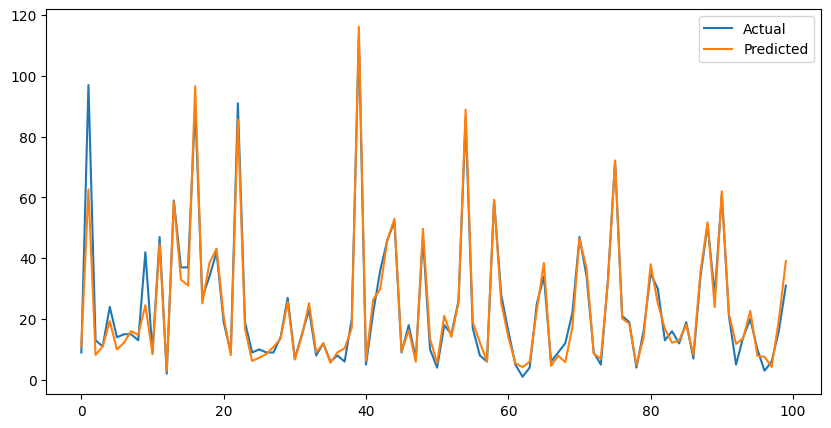

In [18]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label='Actual')
plt.plot(pred_rf[:100], label='Predicted')
plt.legend()
plt.show()

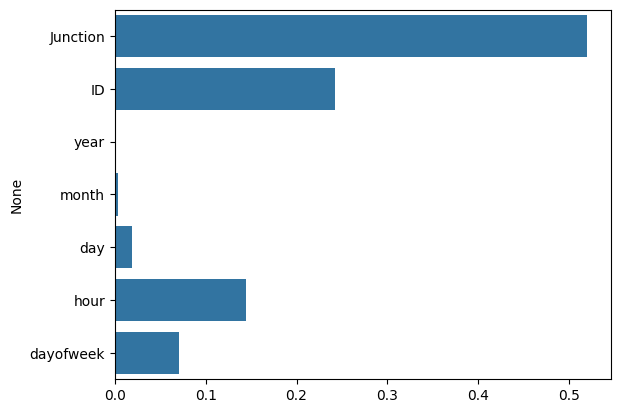

In [19]:
importance = rf.feature_importances_
features = X.columns
sns.barplot(
    x=importance,
    y=features
)
plt.show()

# PHASE 13 — Conclusion

**Which model performed best**
XGBoost and Random Forest outperformed traditional regression models because they captured nonlinear traffic patterns more effectively.

**Which had lowest error**
Ensemble methods like XGBoost or Random Forest are expected to yield the lowest MSE and RMSE.

**Which generalized best**
Random Forest and Gradient Boosting models capture non-linear traffic patterns effectively while avoiding extreme overfitting (if tuned well).